# Step 1. Text processing and chunking

In [23]:
import os
import re
import pandas as pd
import pylab as pl
import pickle
from hashlib import md5
from langchain_text_splitters import MarkdownHeaderTextSplitter

In [24]:
DATA_PATH = './data'
SPLITS_PATH = './splits'
MIN_SPLIT_SIZE = 500
TRUNCATE = 12000

### Text

In [25]:
with open(os.path.join(DATA_PATH, 'virtual_light.txt'), 'rt',  encoding='utf-8') as f:
    text = f.read()

In [26]:
text[:1000]

'Уильям Гибсон. Виртуальный свет\n\n\n---------------------------------------------------------------\n     Гибсон У. Виртуальный свет.\n     Перевод М.А.Пчелинцева\n     СПб., Азбука, 2001\n     Текст взят с https://www.lib.ru\n\t Главы 2 - 39, для образовательных целей\n---------------------------------------------------------------\n\n\n\n2\n\n     "ГРОМИЛА" В ДЕЛЕ\n\n     Машины "Интенсекьюра"  выходят на  патрулирование  по щадящему графику:\nсмена  рабочая,   две   смены  отдыха.   Мыли  их  исключительно  в  большом\nспециализированном заведении  рядом с  Колби - двадцать слоев эмали  "свежий\nмед", ручная шлифовка; к такой роскоши поневоле начнешь относиться бережно.\n     Тем  памятным ноябрьским  вечером, когда Держава Желаний положила конец\nего карьере на  поприще вооруженной охраны, Берри Райделл пришел в автомойку\nчуть раньше времени.\n     Ему там  нравилось. Запах розоватого раствора,  которым снимали с машин\nдорожную грязь, приводил на память последние школь-\n     н

### Text processing and heading marking

In [27]:
txt = re.sub(r'\n\-\-\-[\s\S]*?\-\-\-\n\n', '\n', text)  # drop plate with book info

txt = '# ' + txt.strip()  # mark title
txt = re.sub(r'(\d{1,2})\n\n\s{5}', r'## \1. ', txt)  # mark chapters
txt = re.sub(r'\n\n([А-Я]{5,}\n)\n', r'\n\n## \1', txt)  # mark Acknowledgments as chapters
txt = re.sub(r'\n\n\s{5}', r'\n\n###\n', txt)  # mark chapter sections
txt = re.sub(r'([А-Яа-я0-9])\n([А-Яа-я0-9])', r'\1 \2', txt)  # concatenate strings

txt = re.sub(r' {2,}', ' ', txt)  # remove multiple whitespaces
txt = re.sub(r'\n ', '\n', txt)  # remove left whitespaces 
txt = re.sub(r'([а-я])-\n', r'\1', txt)  # remove hyphens

txt = re.sub(r'([а-я\,\"])\n([а-я\"])', r'\1 \2', txt)  # additional concatenate strings
md_text = re.sub(r'([а-я])\n\-', r'\1 - ', txt).strip()

In [28]:
md_text[:1000]

'# Уильям Гибсон. Виртуальный свет\n\n\n\n\n## 2. "ГРОМИЛА" В ДЕЛЕ\n\n###\nМашины "Интенсекьюра" выходят на патрулирование по щадящему графику:\nсмена рабочая, две смены отдыха. Мыли их исключительно в большом специализированном заведении рядом с Колби - двадцать слоев эмали "свежий мед", ручная шлифовка; к такой роскоши поневоле начнешь относиться бережно.\nТем памятным ноябрьским вечером, когда Держава Желаний положила конец его карьере на поприще вооруженной охраны, Берри Райделл пришел в автомойку чуть раньше времени.\nЕму там нравилось. Запах розоватого раствора, которым снимали с машин дорожную грязь, приводил на память последние школьные каникулы, летнюю халтурку, которую он подыскал себе тогда в Ноксвилле. Громадный жилой дом на улице Джефферсона Дэвиса решили переделать в кондоминиум, а для начала полностью раскурочили. Нужно было обдирать шлакоблочные стены, но обдирать не совсем, а чтобы кое-где, на стыках и в углублениях, оставались следы старой розовой краски - такой вот и

In [29]:
def chunks_truncating(text:str, max_size:int) -> str:
    result_text = ''
    chunks_list_start = text.split(sep='\n\n###\n')
    chunks_list_start_len = len(chunks_list_start)
    print(f'Chunks before truncating: {chunks_list_start_len}')

    for chunk in chunks_list_start:
        if len(chunk) > max_size:
            new_chunk = ''
            inner_strings_list = chunk.split('\n')
            count = len(inner_strings_list)
            for _ in range(count):
                string = inner_strings_list.pop(0)
                new_chunk += f'{string}\n'
                if len(new_chunk) > max_size and not string.startswith('- '):
                    new_chunk += f'\n###\n'
                    new_chunk += '\n'.join(inner_strings_list)
                    break
            result_text += f'{new_chunk}\n\n###\n'
        else:
            result_text += f'{chunk}\n\n###\n'

    last_split_idx = result_text.rfind('\n\n###\n')
    result_text = result_text[:last_split_idx]
    
    chunks_list_end = result_text.split(sep='\n\n###\n')
    chunks_list_end_len = len(chunks_list_end)
    print(f'Chunks after truncating: {chunks_list_end_len}')
    return result_text

md_text = chunks_truncating(text=md_text, max_size=TRUNCATE)

Chunks before truncating: 95
Chunks after truncating: 108


In [30]:
def chunks_gluing(text:str, min_size:int) -> str:
    chunks_list = text.split(sep='\n\n###\n')
    result_text = chunks_list[0]
    print(f'Chunks before gluing: {len(chunks_list)}')

    for chunk in chunks_list[1:]:
        if len(chunk) < min_size:
            result_text += f'\n\n{chunk}'
        else:
            result_text += f'\n\n###\n{chunk}'

    chunks_list = result_text.split(sep='\n\n###\n')
    print(f'Chunks after gluing: {len(chunks_list)}')
    return result_text

md_text = chunks_gluing(text=md_text, min_size=MIN_SPLIT_SIZE)
md_text = md_text.strip()

Chunks before gluing: 108
Chunks after gluing: 100


#### Naming third-level headings

In [31]:
# Header3 naming
md_text = re.sub(r'\n\n###\n(.{5,25}[ \,\.\-\?])', r'\n\n### \1\n\1', md_text)
md_text = md_text.split('\n')
clear_headers_text = ''
for string in md_text:
    if string.startswith('###'):
        string = re.sub(r'[\-\,\;\:\?\!]', '', string)
        string = re.sub(r' {2,}', ' ', string)
        string = string.strip() + '...'
    clear_headers_text += f'{string.strip()}\n'
md_text = clear_headers_text

In [32]:
md_text[-1000:]

' тюрьме штата Юта. Умерли, стойко отказываясь от прививки, запатентованной на имя Шейпли.\nНа суде они молчали. Перед оглашением приговора шестеро отказались от последнего слова, а седьмой, вожак, сказал, что СПИД - кара Господня, воздаяние грешникам по грехам их. Документальные пленки сохранили облик этих убийц Именем Божьим -  сухопарые мужчины с наголо выбритыми головами и пустыми, стеклянными глазами, такими и останутся они в истории, в памяти людской.\nЯмадзаки подошел к лавке и встал в довольно длинную очередь.\nК концу недолгой своей жизни Шейпли стал очень богатым человеком. Может быть, он даже был счастлив. Он успел увидеть, как продукт, полученный из его крови, остановил наползавшую на мир тьму. Опасных болезней много, с каждым годом их количество нарастает - и все же живая вакцина Шейпли спасла бессчетные миллионы жизней.\nЯмадзаки решил, что обязательно посмотрит на парад. Только бы не забыть записную книжку.\nОн дышал запахом свежесмолотого кофе и терпеливо ждал своей оче

#### Saving and restoring Markdown text

In [33]:
with open(os.path.join(DATA_PATH, 'virtual_light.md'), 'wt',  encoding='utf-8') as f:
    f.write(md_text)

In [34]:
with open(os.path.join(DATA_PATH, 'virtual_light.md'), 'rt',  encoding='utf-8') as f:
    md_text = f.read()

### Markdown splitting

In [35]:
headers_to_split_on = [
    ("#", "title"),
    ("##", "chapter"),
    ("###", "section"),
]
markdown_splitter = MarkdownHeaderTextSplitter(headers_to_split_on)
splits = markdown_splitter.split_text(md_text)

In [36]:
len(splits)

100

#### Add metadata to content and save

In [37]:
for s in splits:
    chapter = s.metadata.get('chapter')
    text_cut = s.page_content[:500]
    s.page_content = f'{chapter.strip() if chapter else ''}\n\n{s.page_content}'
    s.metadata['id'] = md5(text_cut.encode()).hexdigest()
    s.metadata['size'] = len(s.page_content)
    s.metadata['collection'] = 'Virtual_Light'

In [50]:
splits[91]

Document(metadata={'title': 'Уильям Гибсон. Виртуальный свет', 'chapter': '36. ЗАПИСНАЯ КНИЖКА (2)', 'section': 'Залитый солнцем город с...', 'id': 'ad3133e20353be9a58a78d2922391d85', 'size': 555, 'collection': 'Virtual_Light'}, page_content='36. ЗАПИСНАЯ КНИЖКА (2)\n\nЗалитый солнцем город, с крыши этой крошечной, прилепившейся к устою коробки. Люк открыт. Слышно, как Скиннер перебирает свое имущество. Медленно наполняет картонный ящик предметами, которые я должен отнести вниз, туда, где торговцы старьем раскладывают свой товар на вытертых одеялах и грязных, насквозь промасленных кусках брезента. Осака далеко. Ветер приносит обрывки песни, стук молотка. Сегодня утром Скиннер поинтересовался, видел ли я в штейнеровском аквариуме щуку.\n- Нет.\n- Она не двигается, Скутер. Совсем не двигается.')

In [39]:
with open(os.path.join(SPLITS_PATH, 'splits.pkl'), 'wb') as f:
    pickle.dump(splits, f)

### Analysis of the distribution of chunks lengths

In [40]:
splits_size = []
for s in splits:
    splits_size.append(len(s.page_content))

In [41]:
# print('min', min(splits_size))
# print('max', max(splits_size))

In [42]:
# After truncating and gluing
print('min', min(splits_size))
print('max', max(splits_size))
# before truncating and gluing:
# min 131
# max 24404

min 555
max 12749


In [43]:
df = pd.DataFrame(splits_size, columns=['size'])
df.sort_values(by='size', ascending=True).head(5)

,size
91,555
86,574
21,707
10,734
39,756


In [44]:
df.sort_values(by='size', ascending=False).head(5)

,size
31,12749
62,12357
0,12329
13,12316
55,12262


In [49]:
splits[91]

Document(metadata={'title': 'Уильям Гибсон. Виртуальный свет', 'chapter': '36. ЗАПИСНАЯ КНИЖКА (2)', 'section': 'Залитый солнцем город с...', 'id': 'ad3133e20353be9a58a78d2922391d85', 'size': 555, 'collection': 'Virtual_Light'}, page_content='36. ЗАПИСНАЯ КНИЖКА (2)\n\nЗалитый солнцем город, с крыши этой крошечной, прилепившейся к устою коробки. Люк открыт. Слышно, как Скиннер перебирает свое имущество. Медленно наполняет картонный ящик предметами, которые я должен отнести вниз, туда, где торговцы старьем раскладывают свой товар на вытертых одеялах и грязных, насквозь промасленных кусках брезента. Осака далеко. Ветер приносит обрывки песни, стук молотка. Сегодня утром Скиннер поинтересовался, видел ли я в штейнеровском аквариуме щуку.\n- Нет.\n- Она не двигается, Скутер. Совсем не двигается.')

In [46]:
# pl.title("Histogram of Сhunk sizes before truncating and gluing")
# pl.xlabel("Size in symbols")
# pl.ylabel("Amt")
# df['size'].hist(figsize=(7, 4), bins=10)
# pl.savefig('hist_before.png')

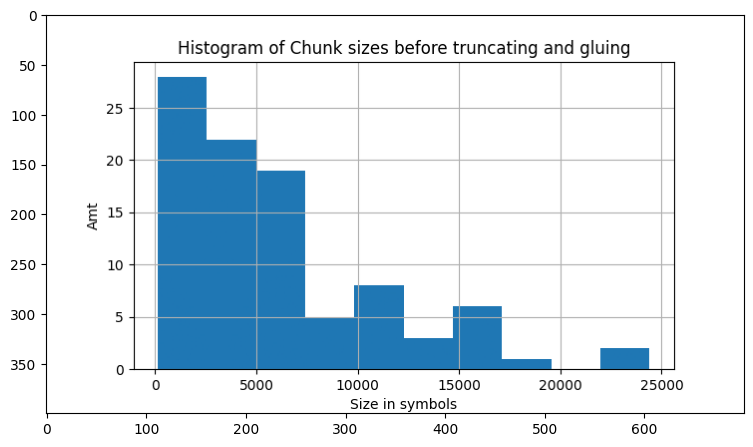

In [47]:
img = pl.imread('hist_before.png')
fig, ax = pl.subplots(figsize=(9, 6))
pl.imshow(img)
pl.show()

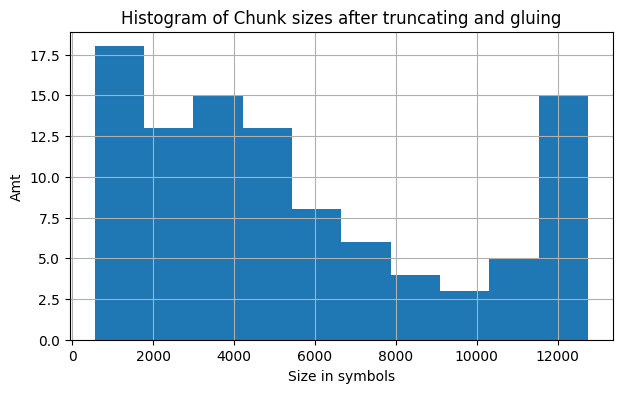

In [48]:
pl.title("Histogram of Сhunk sizes after truncating and gluing")
pl.xlabel("Size in symbols")
pl.ylabel("Amt")
df['size'].hist(figsize=(7, 4))
pl.savefig('hist_after.png')